## About
this way the autoencoder works somehow but the shape it learned is poor quality and it just does not fit even though it finds outliers similarly to linear model or ML algorithms

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

In [4]:
from anomaly_detection.utils.plotting_styles import apply_global_style

In [5]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [7]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [8]:
from torch.utils.data import Dataset, DataLoader
from anomaly_detection.utils.autoencoders import HistDataset

In [38]:
import torch.nn as nn

class AE_low(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=1, kernel_size=4, stride=2),
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.Conv1d(in_channels=1, out_channels=1, kernel_size=2, stride=2),
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.Conv1d(in_channels=1, out_channels=1, kernel_size=2),
            nn.BatchNorm1d(1),
            nn.Sigmoid(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=2),
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=2, stride=2, output_padding=1),
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.ConvTranspose1d(in_channels=1, out_channels=1, kernel_size=4, stride=2),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [39]:
def wasserstein_1d_loss(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-8):
    """
    p, q: shape (batch_size, 96)
    assumes non-negative values
    """

    # normalize to probability distributions
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)

    # cumulative distribution functions
    cdf_p = torch.cumsum(p, dim=-1)
    cdf_q = torch.cumsum(q, dim=-1)

    # W1 distance
    loss = torch.mean(torch.abs(cdf_p - cdf_q).sum(dim=-1))
    return loss

In [89]:
from anomaly_detection.utils.autoencoders import HistDataset

batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = AE_low()

def loss_fct(x, y):
    return 0.95 * nn.KLDivLoss()(x, y) + 0.05 * nn.MSELoss()(x, y)

criterion = wasserstein_1d_loss
lam = 9e-4
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.0004)

In [90]:
from anomaly_detection.utils.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=250, 
                                             dataloader=train_loader, 
                                             model=ae_conv, 
                                             val_loader=test_loader, 
                                             optimizer=optimizer, 
                                             criterion=criterion,
                                             add_regularization=True,
                                             lam=lam,
                                             save_checkpoints=False,
                                             saving_after_epoch=20,
                                             model_name="ae_conv_v3.1_Wass_Reg",
                                             input_dim=96,
                                             latent_dim=24)

Ep [0 / 250]: Train loss 10.449838817119598 | test loss 10.707877159118652
Ep [25 / 250]: Train loss 6.506858514977476 | test loss 6.045147776603699
Ep [50 / 250]: Train loss 3.685206134873873 | test loss 3.6106120347976685
Ep [75 / 250]: Train loss 3.5527353796056644 | test loss 3.4918093085289
Ep [100 / 250]: Train loss 3.433810309954579 | test loss 3.430484175682068
Ep [125 / 250]: Train loss 3.3598628350914277 | test loss 3.3943490386009216
Ep [150 / 250]: Train loss 3.320350116669797 | test loss 3.3557432889938354
Ep [175 / 250]: Train loss 3.29050124118301 | test loss 3.3328487873077393
Ep [200 / 250]: Train loss 3.2671990898115695 | test loss 3.3100199103355408
Ep [225 / 250]: Train loss 3.2504849133746703 | test loss 3.2915881872177124


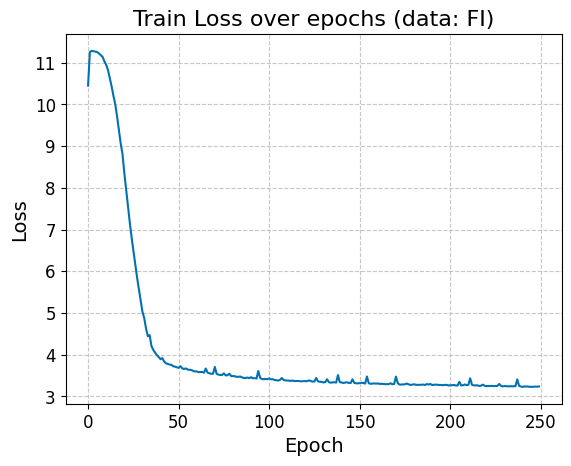

In [91]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

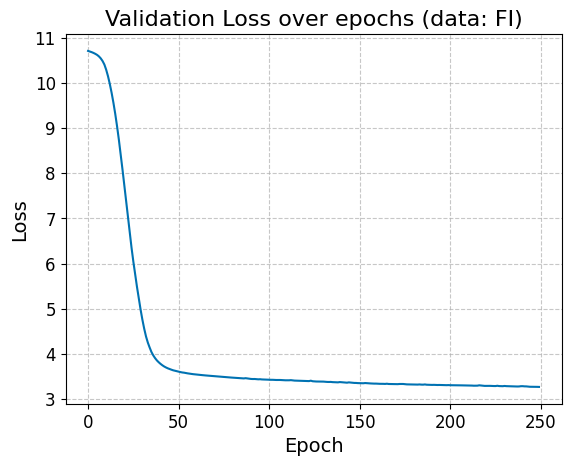

In [92]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [93]:
full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

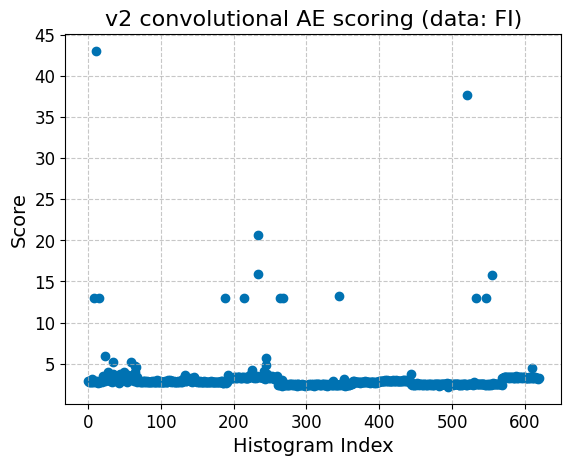

In [94]:
apply_global_style()
plt.title("v2 convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pred = ae_conv(pt.reshape(1,1,96))
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

plt.scatter(range(len(score)), score)
plt.show()

In [95]:
outliers = np.where(np.array(score) > 0.14)
outliers

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177

In [96]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.reshape(1, 1, 96)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


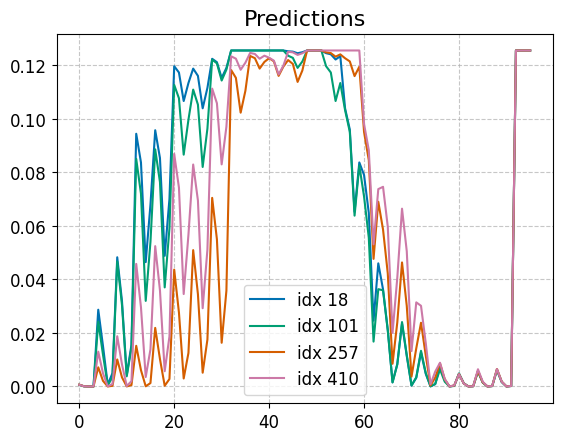

In [97]:
def plot_selected(preds, indices):
    if len(indices) != 4:
        raise ValueError("Exactly 4 indices must be provided.")

    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()

    preds = np.asarray(preds)

    if preds.ndim == 1:
        values = preds[indices]

        plt.figure()
        plt.bar(range(4), values)
        plt.xticks(range(4), indices)
        plt.title("Selected indices")
        plt.show()

    elif preds.ndim >= 2:
        plt.figure()
        for idx in indices:
            plt.plot(preds[idx], label=f"idx {idx}")

        plt.legend()
        plt.title("Predictions")
        apply_global_style()
        plt.show()

    else:
        raise ValueError("Unsupported tensor shape.")

plot_selected(preds, [18, 101, 257, 410])

tensor(0.1483)


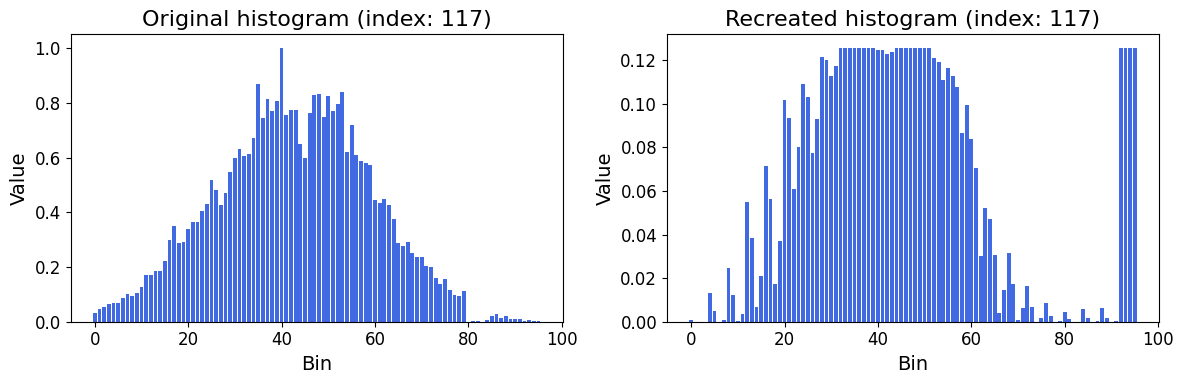

In [102]:
idx = 117

ae_conv.eval()
pred = ae_conv(full_dataset[idx].reshape(1, 1, 96)).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
plt.tight_layout()
print(loss)
plt.show()

In [99]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [11, 520, 233, 234, 555, 344, 8, 15, 188, 214]
lowest scores [266, 353, 494]


In [100]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

save_model = False

if save_model:
    torch.save({
        "model_state_dict": ae_conv.state_dict(),
        "config": {
            "input_dim": 96,
            "latent_dim": 14,
            "num_latent_space_embeddings" : 32
        }
    }, f"{CHECKPOINT_DIR}/conv_autoenc_v3.pth")